# Decision Trees — A Comprehensive Demo

Decision Trees are one of the most intuitive and widely used supervised learning algorithms. They work by recursively partitioning the feature space into regions, making predictions based on simple decision rules inferred from the data.

## Key Concepts

**Splitting Criteria**
- **Gini Impurity**: Measures the probability of incorrectly classifying a randomly chosen element. For a node with classes *k*: `G = 1 - sum(p_k^2)`
- **Entropy / Information Gain**: Measures the disorder (uncertainty) in a set. Splits are chosen to maximise the information gain: `H = -sum(p_k * log2(p_k))`

**Regularisation / Pruning**
- `max_depth` — limits how deep the tree can grow
- `min_samples_split` — minimum samples required to split a node
- `min_samples_leaf` — minimum samples required at a leaf node
- **Post-pruning** — grow a full tree, then remove branches that do not improve generalisation

---

In this notebook we will:
1. Load and explore a binary classification dataset
2. Train Decision Trees with different criteria
3. Tune hyperparameters with cross-validation
4. Evaluate and visualise the best model
5. Generate predictions on unseen test data

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from data_loader import (
    load_training_data,
    load_testing_data,
    load_sample_submission,
    split_features_target,
    FEATURE_COLUMNS,
)
from model import (
    train_decision_tree,
    evaluate_model,
    predict,
    tune_hyperparameters,
    generate_submission,
)
from visualization import (
    plot_class_distribution,
    plot_feature_distributions,
    plot_correlation_heatmap,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_decision_tree,
)

sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

%matplotlib inline

## 2. Load & Explore Data

The dataset lives in `Dataset/` and consists of three CSV files:
- **training.csv** — 9 integer features + 1 binary target (no header)
- **testing.csv** — 9 features only (no header, no labels)
- **sample.csv** — submission template with `id` and `class` columns

In [2]:
train_df = load_training_data()
test_df = load_testing_data()
sample_sub = load_sample_submission()

print(f"Training set shape : {train_df.shape}")
print(f"Testing set shape  : {test_df.shape}")
print(f"Sample submission   : {sample_sub.shape}")
print()
train_df.head(10)

Training set shape : (174, 10)
Testing set shape  : (174, 9)
Sample submission   : (174, 2)



,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,7,4,5,3,6,1,7,8,4,1
1,6,7,8,2,4,2,7,1,5,1
2,1,9,10,7,4,8,7,1,5,1
3,8,2,2,2,3,2,3,2,2,0
4,6,3,3,3,3,3,5,3,3,0
5,2,2,2,2,3,6,2,2,2,0
6,2,2,2,2,3,2,2,2,2,0
7,3,2,2,2,3,2,5,2,2,0
8,8,2,2,2,3,2,5,2,2,0
9,2,2,2,2,3,9,3,2,2,0


In [3]:
train_df.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
count,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000
mean,4.948276,3.287356,3.701149,3.143678,4.011494,2.770115,4.672414,3.045977,2.522989,0.367816
std,2.741813,2.369888,2.638597,2.097904,2.082097,2.230639,2.353607,2.295550,1.425223,0.483603
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,2.000000,0.000000
50%,5.000000,2.000000,2.000000,2.000000,3.000000,2.000000,5.000000,2.000000,2.000000,0.000000
75%,7.000000,5.000000,5.000000,4.000000,5.000000,2.000000,6.000000,3.000000,2.000000,1.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000


In [4]:
print("Missing values per column:")
print(train_df.isnull().sum())
print(f"\nTotal missing: {train_df.isnull().sum().sum()}")

Missing values per column:
feature_1    0
feature_2    0
feature_3    0
feature_4    0
feature_5    0
feature_6    0
feature_7    0
feature_8    0
feature_9    0
target       0
dtype: int64

Total missing: 0


In [6]:
X, y = split_features_target(train_df)
print(f"Features shape: {X.shape}")
print(f"Target shape  : {y.shape}")

Features shape: (174, 9)
Target shape  : (174,)


## 3. Exploratory Data Analysis

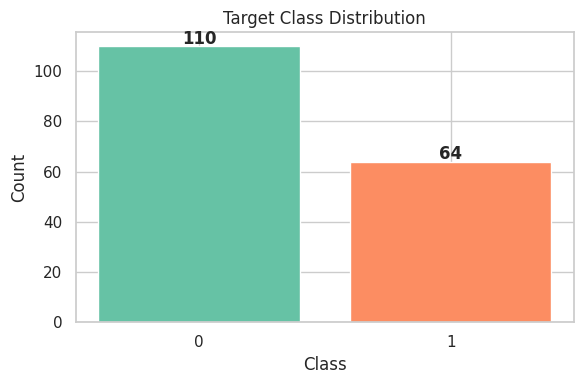

In [7]:
plot_class_distribution(y)
plt.show()

/workspaces/Pytorch-environment/ML_concepts/Decision_Trees/visualization.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x="target", y=feat, ax=axes[i],
/workspaces/Pytorch-environment/ML_concepts/Decision_Trees/visualization.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x="target", y=feat, ax=axes[i],
/workspaces/Pytorch-environment/ML_concepts/Decision_Trees/visualization.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x="target", y=feat, ax=axes[i],
/workspaces/Pytorch-environm

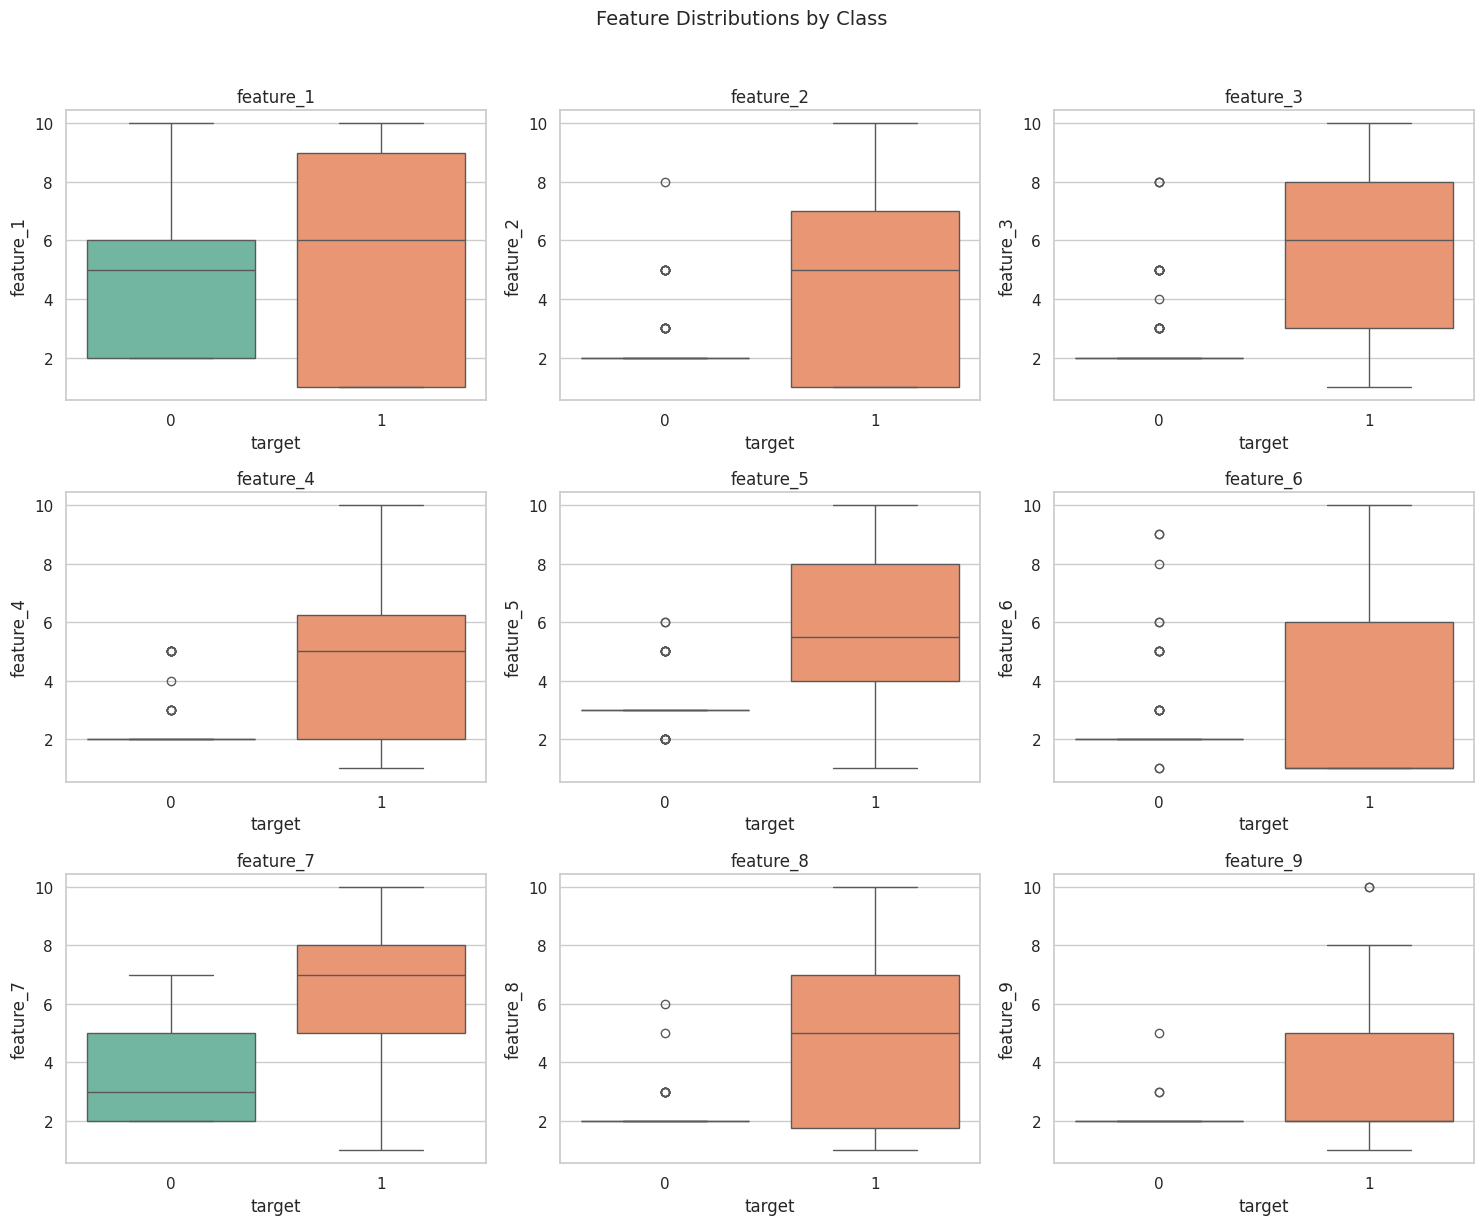

In [8]:
plot_feature_distributions(X, y)
plt.show()

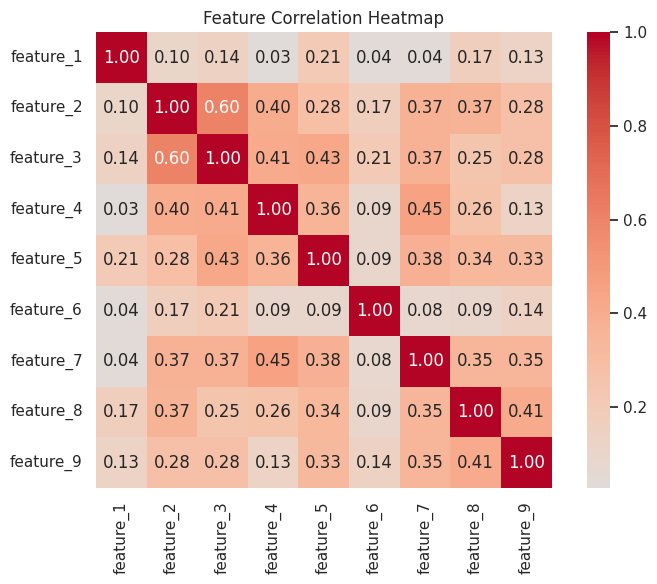

In [9]:
plot_correlation_heatmap(X)
plt.show()

## 4. Train / Validation Split

We use an 80/20 stratified split so the class proportions are preserved in both sets.

In [10]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Validation set : {X_val.shape[0]} samples")
print(f"\nTraining class distribution:\n{y_train.value_counts()}")
print(f"\nValidation class distribution:\n{y_val.value_counts()}")

Training set   : 139 samples
Validation set : 35 samples

Training class distribution:
target
0    88
1    51
Name: count, dtype: int64

Validation class distribution:
target
0    22
1    13
Name: count, dtype: int64


## 5. Train Decision Tree — Gini Criterion

We start with the default Decision Tree using **Gini impurity** as the splitting criterion and no depth limit.

In [11]:
gini_tree = train_decision_tree(
    X_train, y_train, criterion="gini", random_state=RANDOM_STATE
)
gini_results = evaluate_model(gini_tree, X_val, y_val)

print(f"Gini Tree — Validation Accuracy: {gini_results['accuracy']:.4f}")
print(f"Tree Depth: {gini_tree.get_depth()}, Leaves: {gini_tree.get_n_leaves()}")
print(f"\n{gini_results['report']}")

Gini Tree — Validation Accuracy: 0.9143
Tree Depth: 5, Leaves: 9

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        22
           1       0.92      0.85      0.88        13

    accuracy                           0.91        35
   macro avg       0.91      0.90      0.91        35
weighted avg       0.91      0.91      0.91        35



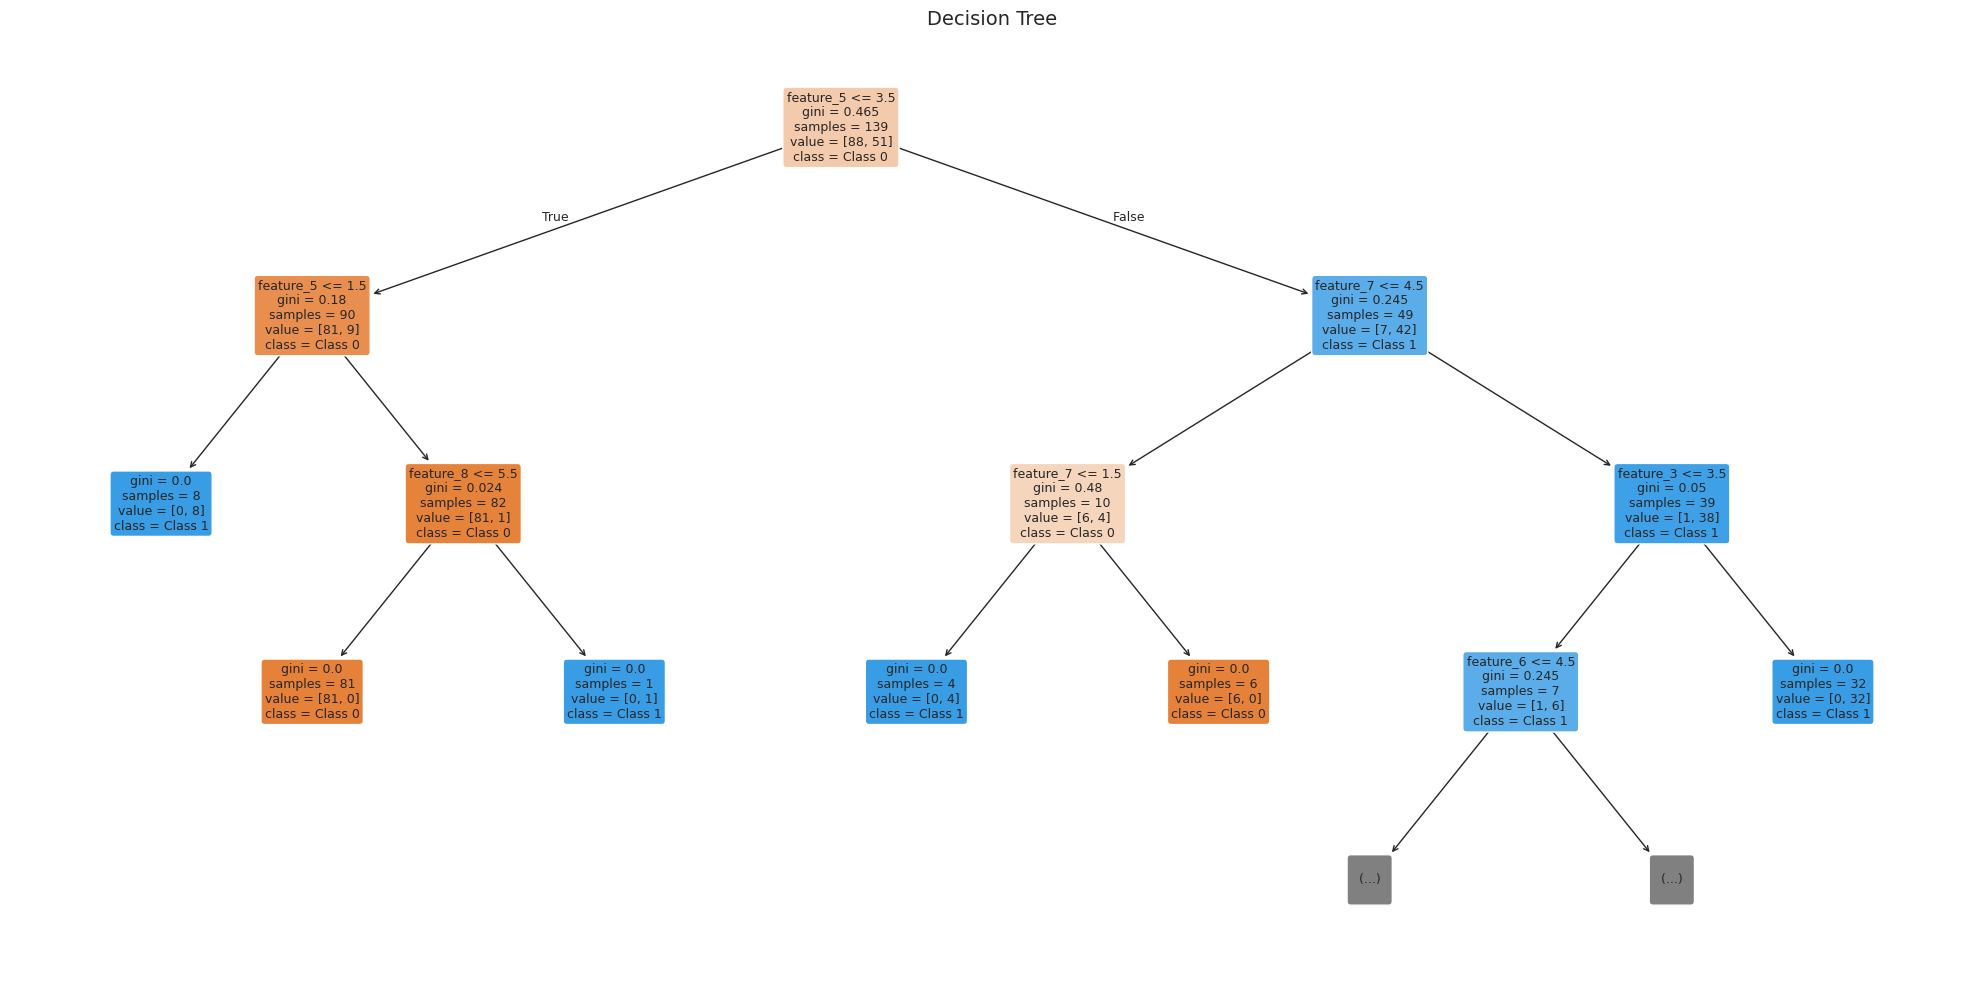

In [12]:
plot_decision_tree(gini_tree, FEATURE_COLUMNS, max_depth=3)
plt.show()

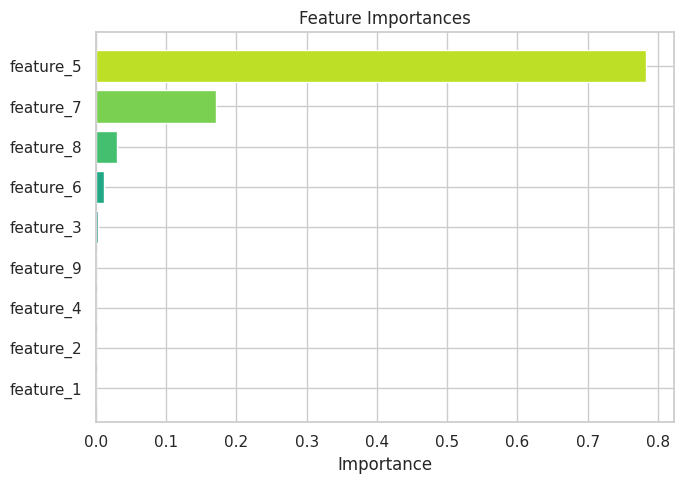

In [13]:
plot_feature_importance(gini_tree, FEATURE_COLUMNS)
plt.show()

## 6. Train Decision Tree — Entropy Criterion

Now we train a second tree using **entropy** (information gain) as the splitting criterion and compare results.

In [14]:
entropy_tree = train_decision_tree(
    X_train, y_train, criterion="entropy", random_state=RANDOM_STATE
)
entropy_results = evaluate_model(entropy_tree, X_val, y_val)

print(f"Entropy Tree — Validation Accuracy: {entropy_results['accuracy']:.4f}")
print(f"Tree Depth: {entropy_tree.get_depth()}, Leaves: {entropy_tree.get_n_leaves()}")
print(f"\n{entropy_results['report']}")

Entropy Tree — Validation Accuracy: 0.9143
Tree Depth: 5, Leaves: 9

              precision    recall  f1-score   support

           0       0.91      0.95      0.93        22
           1       0.92      0.85      0.88        13

    accuracy                           0.91        35
   macro avg       0.91      0.90      0.91        35
weighted avg       0.91      0.91      0.91        35



In [15]:
comparison = pd.DataFrame({
    "Criterion": ["Gini", "Entropy"],
    "Accuracy": [gini_results["accuracy"], entropy_results["accuracy"]],
    "Depth": [gini_tree.get_depth(), entropy_tree.get_depth()],
    "Leaves": [gini_tree.get_n_leaves(), entropy_tree.get_n_leaves()],
})
comparison

,Criterion,Accuracy,Depth,Leaves
0,Gini,0.914286,5,9
1,Entropy,0.914286,5,9


## 7. Hyperparameter Tuning with GridSearchCV

We search over multiple hyperparameter combinations using 5-fold cross-validation to find the best configuration.

In [16]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

search = tune_hyperparameters(
    X_train, y_train, param_grid=param_grid, cv=5, random_state=RANDOM_STATE
)

print(f"Best parameters : {search.best_params_}")
print(f"Best CV accuracy: {search.best_score_:.4f}")

Best parameters : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV accuracy: 0.9426


In [17]:
cv_results = pd.DataFrame(search.cv_results_)
top_10 = cv_results.nsmallest(10, "rank_test_score")[
    ["params", "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score"]
]
top_10

,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
45,"{'criterion': 'entropy', 'max_depth': None, 'm...",0.942593,0.028377,1.000000,1
72,"{'criterion': 'entropy', 'max_depth': 7, 'min_...",0.942593,0.028377,1.000000,1
81,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.942593,0.028377,1.000000,1
0,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.935714,0.041650,1.000000,4
18,"{'criterion': 'gini', 'max_depth': 5, 'min_sam...",0.935714,0.041650,1.000000,4
27,"{'criterion': 'gini', 'max_depth': 7, 'min_sam...",0.935714,0.041650,1.000000,4
36,"{'criterion': 'gini', 'max_depth': 10, 'min_sa...",0.935714,0.041650,1.000000,4
63,"{'criterion': 'entropy', 'max_depth': 5, 'min_...",0.935450,0.026447,0.996412,8
1,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.921429,0.052489,0.992809,9
3,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.921429,0.061445,0.985618,9


## 8. Model Evaluation

Evaluate the best model from GridSearchCV on the held-out validation set.

In [18]:
best_model = search.best_estimator_
best_results = evaluate_model(best_model, X_val, y_val)

print(f"Best Model — Validation Accuracy: {best_results['accuracy']:.4f}")
print(f"Tree Depth: {best_model.get_depth()}, Leaves: {best_model.get_n_leaves()}")
print(f"\nClassification Report:\n{best_results['report']}")

Best Model — Validation Accuracy: 0.9143
Tree Depth: 5, Leaves: 9

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93        22
           1       0.92      0.85      0.88        13

    accuracy                           0.91        35
   macro avg       0.91      0.90      0.91        35
weighted avg       0.91      0.91      0.91        35



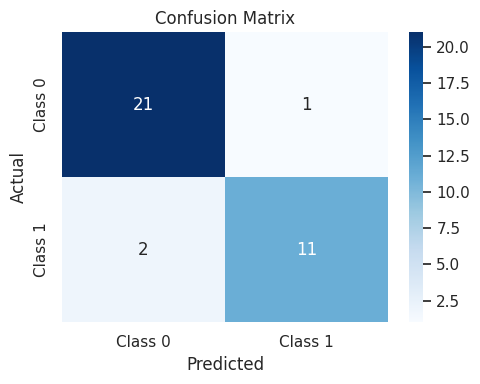

In [19]:
plot_confusion_matrix(best_results["confusion_matrix"])
plt.show()

## 9. Tree Visualization

Visualise the tuned decision tree (limited to depth 3 for readability) and its feature importances.

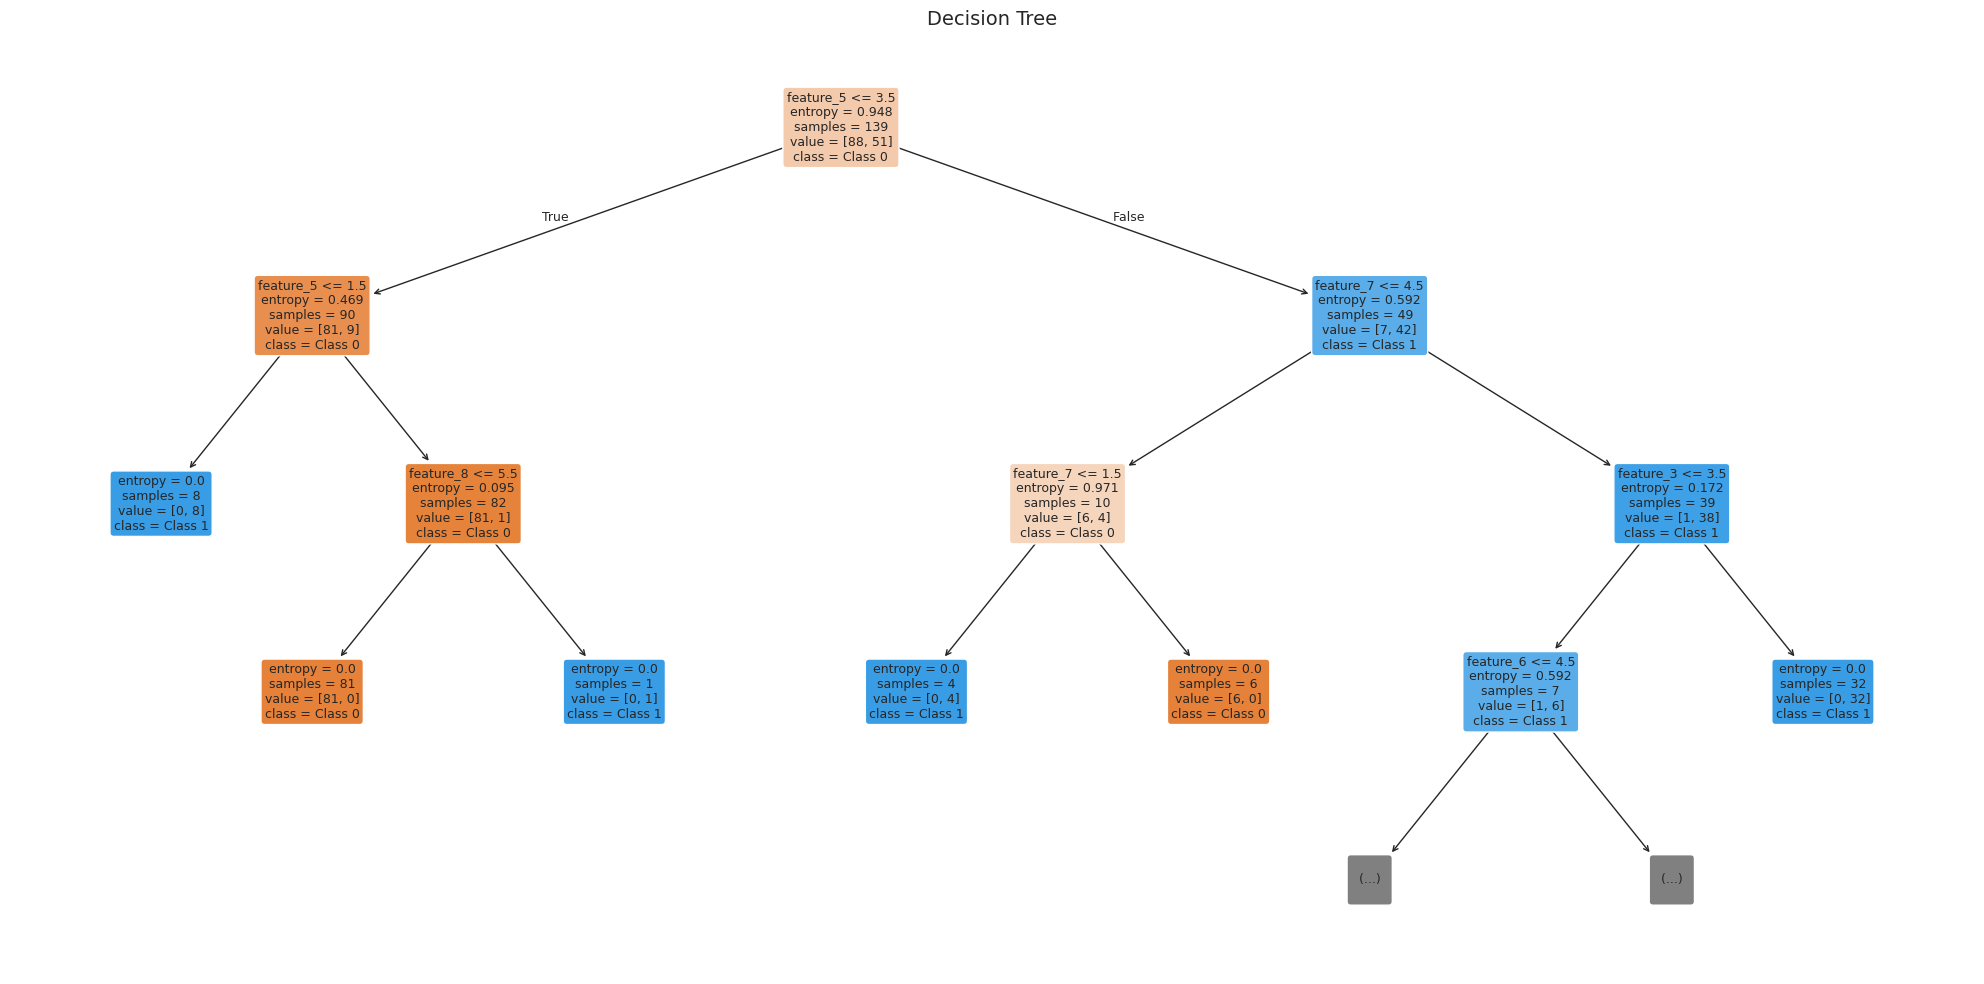

In [20]:
plot_decision_tree(best_model, FEATURE_COLUMNS, max_depth=3)
plt.show()

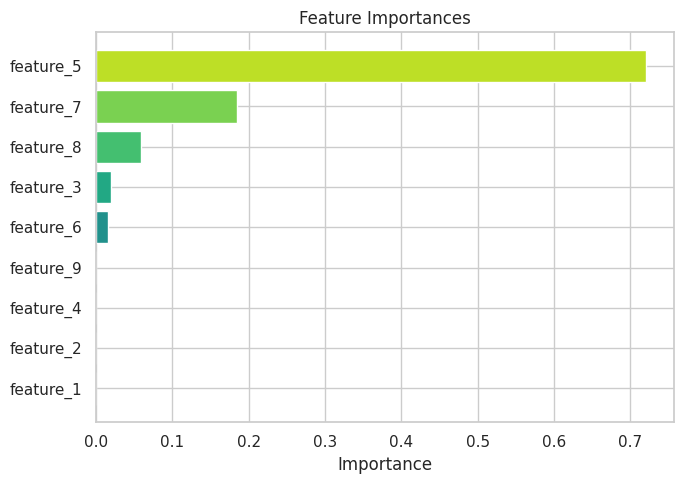

In [21]:
plot_feature_importance(best_model, FEATURE_COLUMNS)
plt.show()

## 10. Generate Test Predictions

Load the unlabelled test set, generate predictions with the best model, and save them in the sample-submission format.

In [22]:
test_preds = predict(best_model, test_df)

print(f"Predictions generated: {len(test_preds)}")
print(f"Class distribution in predictions:\n{pd.Series(test_preds).value_counts().sort_index()}")

Predictions generated: 174
Class distribution in predictions:
0    107
1     67
Name: count, dtype: int64


In [23]:
submission = generate_submission(test_preds, "submission.csv")
print("Submission saved to submission.csv")
submission.head(10)

Submission saved to submission.csv


,id,class
0,1,0
1,2,0
2,3,1
3,4,0
4,5,0
5,6,0
6,7,1
7,8,0
8,9,1
9,10,0


## 11. Conclusion

**Key Takeaways**

1. **Decision Trees are interpretable** — the tree structure makes it easy to understand exactly how predictions are made, which features matter, and what thresholds are used.

2. **Gini vs Entropy** — Both splitting criteria produced comparable results on this dataset. In practice the choice rarely matters much; Gini is slightly faster to compute.

3. **Hyperparameter tuning is essential** — GridSearchCV identified the best combination of `max_depth`, `min_samples_split`, `min_samples_leaf`, and `criterion`, improving generalisation over the unconstrained baseline.

4. **Overfitting risk** — An unconstrained tree will memorise the training data. Regularisation parameters (`max_depth`, `min_samples_leaf`) act as a form of pre-pruning to prevent this.

5. **Feature importance** — The model identifies which features contribute most to the classification, providing insight into the underlying data structure.

**Next Steps**
- Try ensemble methods (Random Forest, Gradient Boosted Trees) that build on Decision Trees
- Experiment with feature engineering or dimensionality reduction
- Evaluate with additional metrics (ROC-AUC, precision-recall curves)